In [2]:
!pip install shap

In [5]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.model_selection import learning_curve

import shap

In [6]:
test = pd.read_csv("../data/test_processed.csv")

X_test = test.drop("depression_label", axis=1)

y_test = test["depression_label"]

model = joblib.load("../models/best_model.pkl")

In [7]:
prediction = model.predict(X_test)

probability = model.predict_proba(X_test)[:,1]

In [8]:
print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

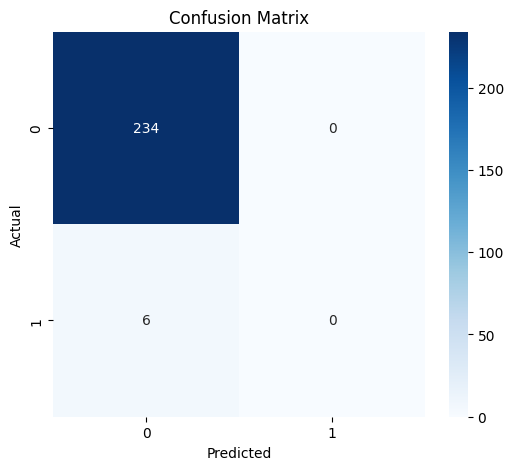

In [9]:
cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

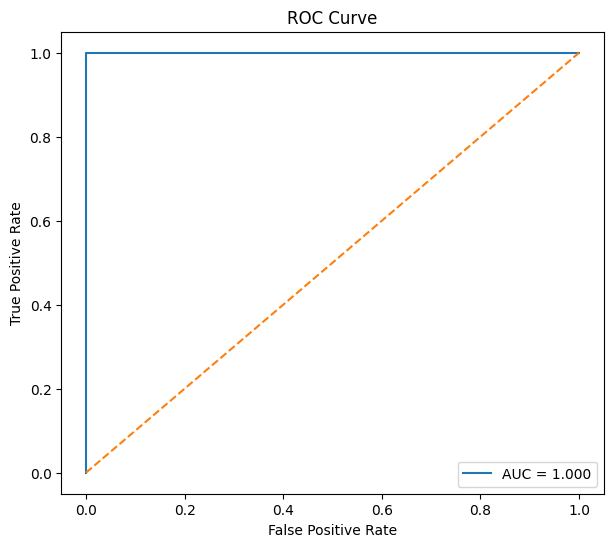

In [10]:
fpr,tpr,_ = roc_curve(
    y_test,
    probability
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

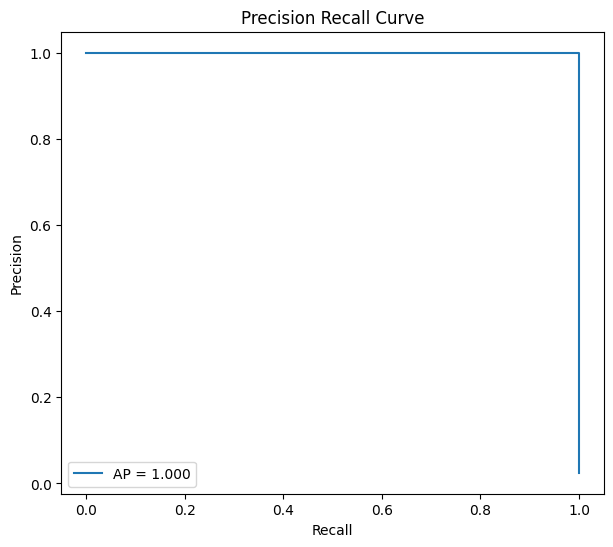

In [11]:
precision, recall, _ = precision_recall_curve(
    y_test,
    probability
)

ap = average_precision_score(
    y_test,
    probability
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap:.3f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.show()

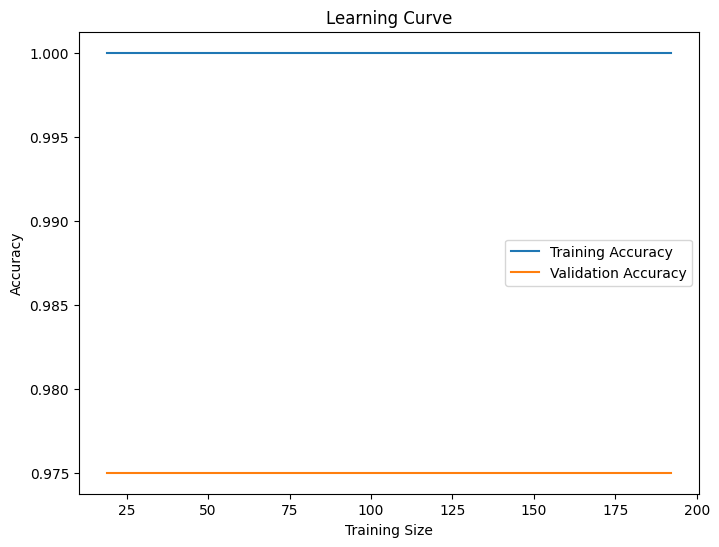

In [12]:
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_test,
    y_test,
    cv=5,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    test_mean,
    label="Validation Accuracy"
)

plt.xlabel("Training Size")

plt.ylabel("Accuracy")

plt.legend()

plt.title("Learning Curve")

plt.show()

In [13]:
importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
2,num__sleep_hours,0.202800
1,num__daily_social_media_hours,0.168764
6,num__stress_level,0.144021
7,num__anxiety_level,0.115871
4,num__academic_performance,0.068817
3,num__screen_time_before_sleep,0.063565
5,num__physical_activity,0.059737
8,num__addiction_level,0.049179
0,num__age,0.038168
10,cat__gender_male,0.019847


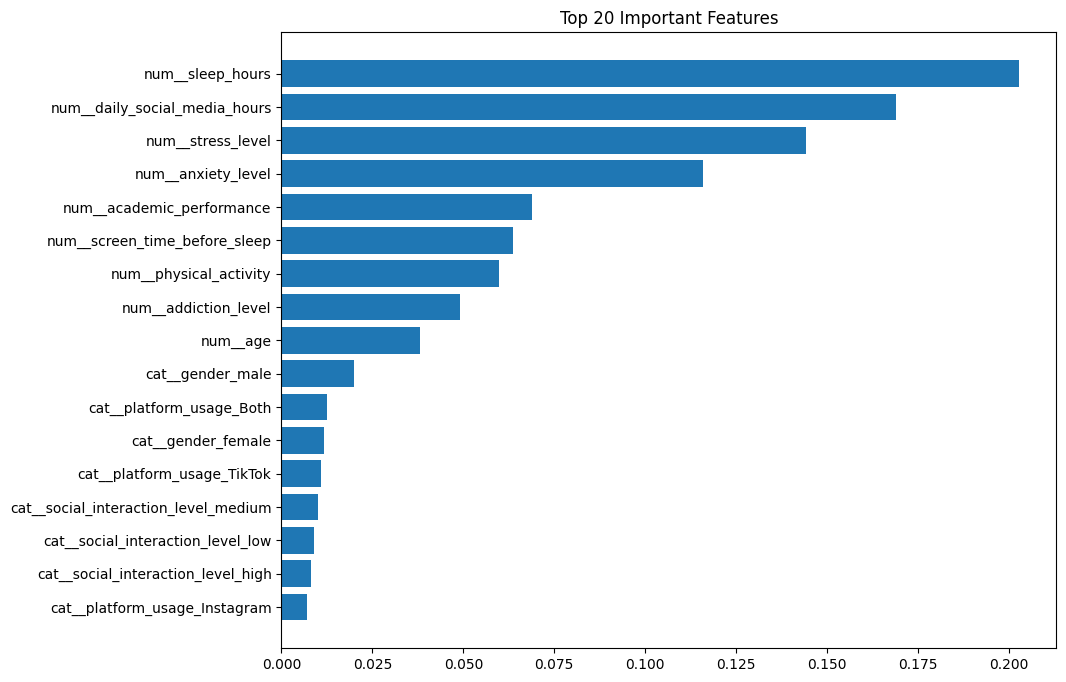

In [14]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["Importance"][:20]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

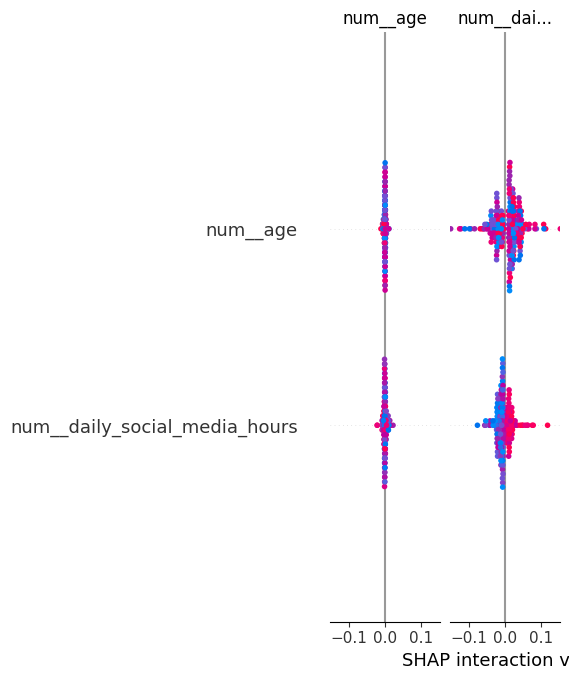

In [15]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

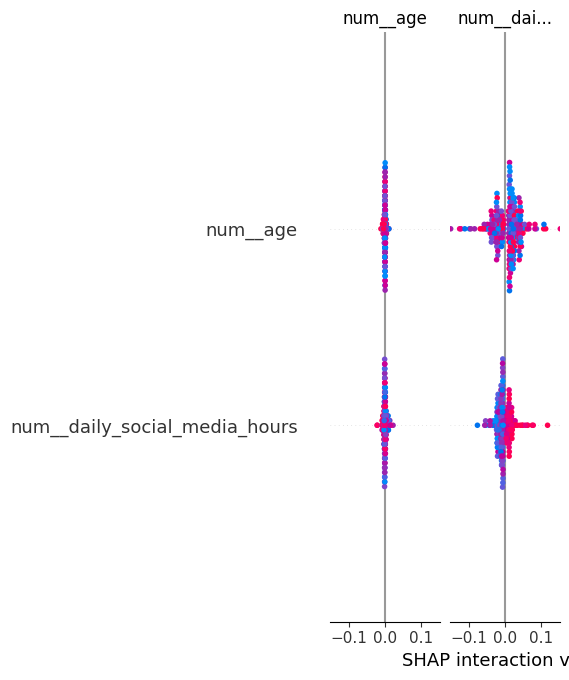

In [16]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [19]:
import os

os.makedirs("../results", exist_ok=True)

plt.savefig("../results/feature_importance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [20]:
plt.savefig("../results/feature_importance.png")

<Figure size 640x480 with 0 Axes>

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :",accuracy_score(y_test,prediction))

print("Precision :",precision_score(y_test,prediction))

print("Recall :",recall_score(y_test,prediction))

print("F1 :",f1_score(y_test,prediction))

Accuracy : 0.975
Precision : 0.0
Recall : 0.0
F1 : 0.0


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
